In [1]:
import os
desired_root_name = "dark-matter-sbi" 
while os.path.basename(os.getcwd()) != desired_root_name:
    os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))
    
import numpy as np
import matplotlib.pyplot as plt
import WimPyDD as WD

<div align="center">

<span style="font-size: 1.5em;">Barebone</span>

</div>

In [2]:
# Proton coupling to operator 1 (r=1): c^1_p=1/M**2 

# SI Hamiltonian
wc = {'1': lambda M, r=1 : [(1.+r)/M**2,(1-r)/M**2]} # r: Proton-neutron coupling ratio, 
                                                     # M: Mass scale of the EFT interaction, usually the mass of the heavy mediator that has been integrated out of the theory
SI = WD.eft_hamiltonian('SI', wc)

# Standard Halo Model
vmin,delta_eta0=WD.streamed_halo_function()

# Experiment
xenon_target = WD.target('Xe')
er_vec=np.linspace(0.1,20,100) 

# WIMP
mchi = 20.

# Theoretical differential event rate in events/kg/day/keV
diff_rate=[WD.diff_rate(xenon_target, SI, mchi, er, vmin, delta_eta0, M=1e3, r=1) for er in er_vec]

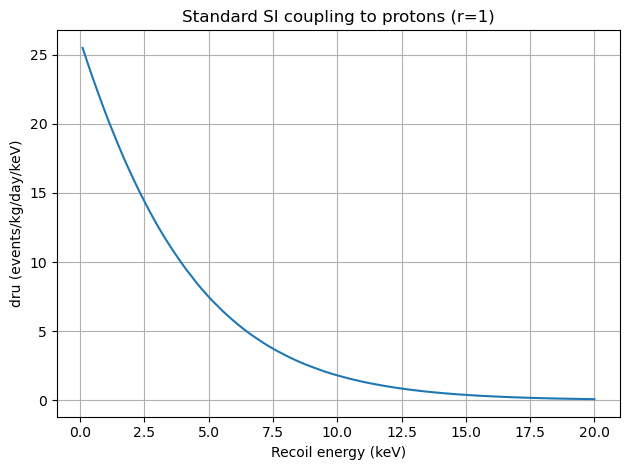

In [3]:
# Plot
plt.plot(er_vec,diff_rate)
plt.xlabel("Recoil energy (keV)")
plt.ylabel("dru (events/kg/day/keV)") 
plt.title("Standard SI coupling to protons (r=1)")
plt.grid()
#plt.yscale('log')
plt.tight_layout()
plt.show()

<div align="center">

<span style="font-size: 1.5em;">Multiple WIMP masses</span>

</div>

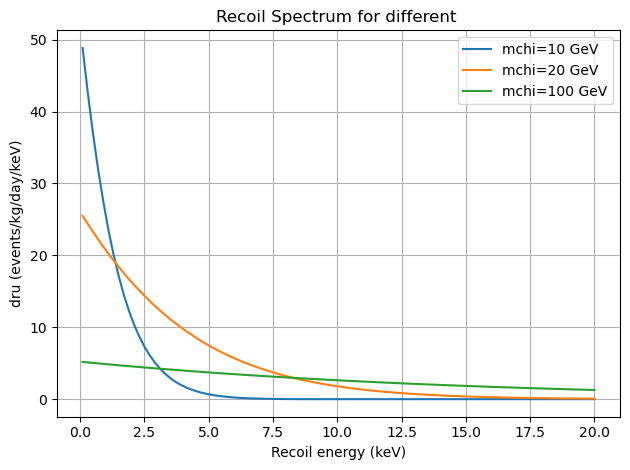

: 

In [ ]:
mchi_values = [10, 20, 50, 100]  # Example WIMP masses in GeV

plt.figure()
for mchi in mchi_values:
    diff_rate = [WD.diff_rate(xenon_target, SI, mchi, er, vmin, delta_eta0, M=1e3, r=1) for er in er_vec]
    plt.plot(er_vec, diff_rate, label=f"mchi={mchi} GeV")

plt.xlabel("Recoil energy (keV)")
plt.ylabel("dru (events/kg/day/keV)")
plt.title("Recoil Spectrum for different ")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

<div align="center">

<span style="font-size: 1.5em;">XENON1T 2018 </span>

</div>

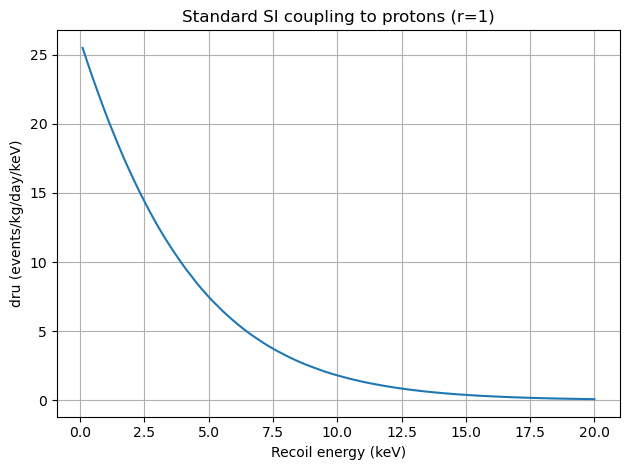

In [6]:
# Initialize experiment that includes quenching factors for NaI
xenon1t_2018 = WD.experiment("XENON_1T_2018")
xenon_target = xenon1t_2018.target

# SI Hamiltonian
wc = {'1': lambda M, r=1 : [(1.+r)/M**2,(1-r)/M**2]} # r: Proton-neutron coupling ratio, 
                                                     # M: Mass scale of the EFT interaction, usually the mass of the heavy mediator that has been integrated out of the theory
SI = WD.eft_hamiltonian('SI', wc)

# Standard Halo Model
vmin,delta_eta0=WD.streamed_halo_function()

er_vec=np.linspace(0.1,20,100)
mchi=20.
diff_rate=[WD.diff_rate(xenon_target, SI, mchi, er, vmin, delta_eta0,M=1e3,r=1) for er in er_vec]
plt.plot(er_vec,diff_rate)
plt.xlabel("Recoil energy (keV)")
plt.ylabel("dru (events/kg/day/keV)")
plt.title("Standard SI coupling to protons (r=1)")
plt.grid()
#plt.yscale('log')
plt.tight_layout()
plt.show()

<div align="center">

<span style="font-size: 1.5em;">MC Generator </span>

</div>

### Simple Model 


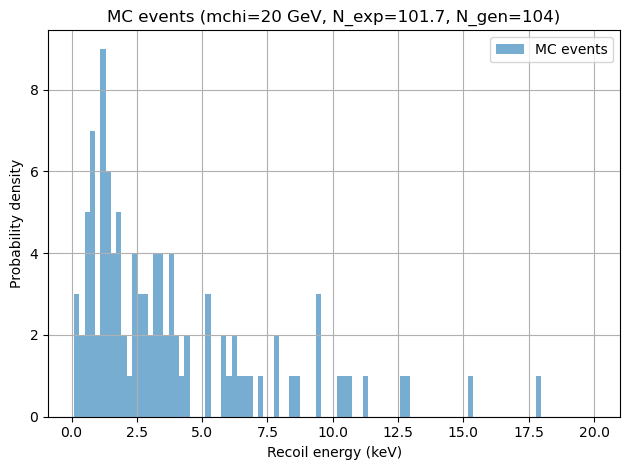

In [7]:
def generate_mc_events(mchi, exposure=100):
    """
    Generate Monte Carlo recoil energies according to the differential rate
    for a given WIMP mass mchi. The total number of events is Poisson-distributed
    with mean given by the integrated expected signal.

    Parameters:
        mchi (float): WIMP mass in GeV
        exposure (float): Exposure in kg*day

    Returns:
        events (np.ndarray): Array of generated recoil energies (keV)
        n_expected (float): Expected mean number of events
        n_generated (int): Actual number of generated events
    """
    er_vec=np.linspace(0.1,20,100)
    diff_rate = np.array([WD.diff_rate(xenon_target, SI, mchi, er, vmin, delta_eta0, M=1e3, r=1) for er in er_vec])
    bin_width = er_vec[1] - er_vec[0]
    expected_events_per_bin = diff_rate * exposure * bin_width
    n_expected = expected_events_per_bin.sum()
    n_generated = np.random.poisson(n_expected)
    # Normalize to get probability for each bin
    prob = expected_events_per_bin / n_expected 
    event_indices = np.random.choice(len(er_vec), size=n_generated, p=prob)
    events = er_vec[event_indices]
    return events, n_expected, n_generated

# Example usage:
events, n_expected, n_generated = generate_mc_events(mchi=20, exposure=1)
plt.hist(events, bins=er_vec, alpha=0.6, label="MC events")
plt.xlabel("Recoil energy (keV)")
plt.ylabel("Probability density")
plt.title(f"MC events (mchi=20 GeV, N_exp={n_expected:.1f}, N_gen={n_generated})")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### Transformation Method (Better)

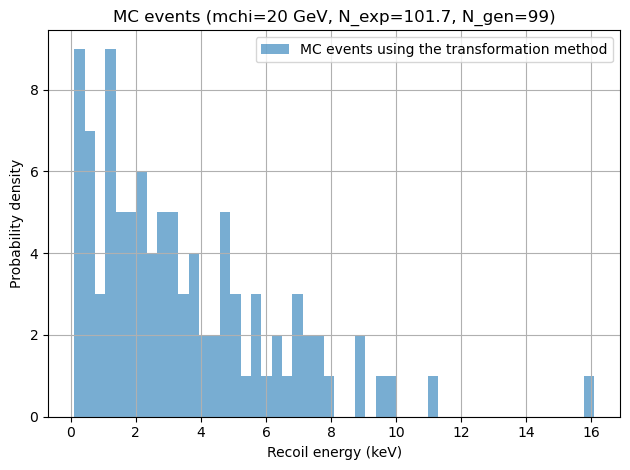

In [8]:
def generate_mc_events_transformation(mchi, exposure=100):
    """
    Generate Monte Carlo recoil energies according to the differential rate
    for a given WIMP mass mchi using the transformation (inverse CDF) method.

    Parameters:
        mchi (float): WIMP mass in GeV
        exposure (float): Exposure in kg*day

    Returns:
        events (np.ndarray): Array of generated recoil energies (keV)
        n_expected (float): Expected mean number of events
        n_generated (int): Actual number of generated events
    """
    # Compute the differential rate at fine energy bins
    er_vec=np.linspace(0.1,20,100)
    diff_rate = np.array([WD.diff_rate(xenon_target, SI, mchi, er, vmin, delta_eta0, M=1e3, r=1) for er in er_vec])
    bin_width = er_vec[1] - er_vec[0]
    expected_events_per_bin = diff_rate * exposure * bin_width
    n_expected = expected_events_per_bin.sum()
    n_generated = np.random.poisson(n_expected)

    # Build the cumulative distribution function (CDF)
    cdf = np.cumsum(expected_events_per_bin)
    cdf = cdf / cdf[-1]  # Normalize to 1

    # Draw uniform random numbers and invert the CDF
    u = np.random.uniform(0, 1, n_generated)
    events = np.interp(u, cdf, er_vec)

    return events, n_expected, n_generated

events, n_expected, n_generated = generate_mc_events_transformation(mchi=20, exposure=1)
plt.hist(events, bins=50, alpha=0.6, label="MC events using the transformation method")
plt.xlabel("Recoil energy (keV)")
plt.ylabel("Probability density")
plt.title(f"MC events (mchi=20 GeV, N_exp={n_expected:.1f}, N_gen={n_generated})")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()